In [ ]:
# 东证的实际交易成本
# 日本股票的成本结构如下：
# 手续费：SBI证券/楽天証券 大约0.055%（含税），小额交易有最低手续费
# 滑点：实际成交价往往比信号价差一点点，保守估计0.05%
# 合计：买入+卖出约 0.2% 一个来回
# 看起来很小，但频繁交易会快速累积。

[*********************100%***********************]  1 of 1 completed


  绩效摘要（含交易成本）
  初始资金         : ¥ 1,000,000
  最终资产         : ¥ 1,206,897
  策略收益率       : +20.69%
  买入持有收益率   : +33.20%
  超额收益         : -12.51%
  总手续费         : ¥     1,740
--------------------------------------------------
  夏普比率         :      1.852
  最大回撤         : -6.74%


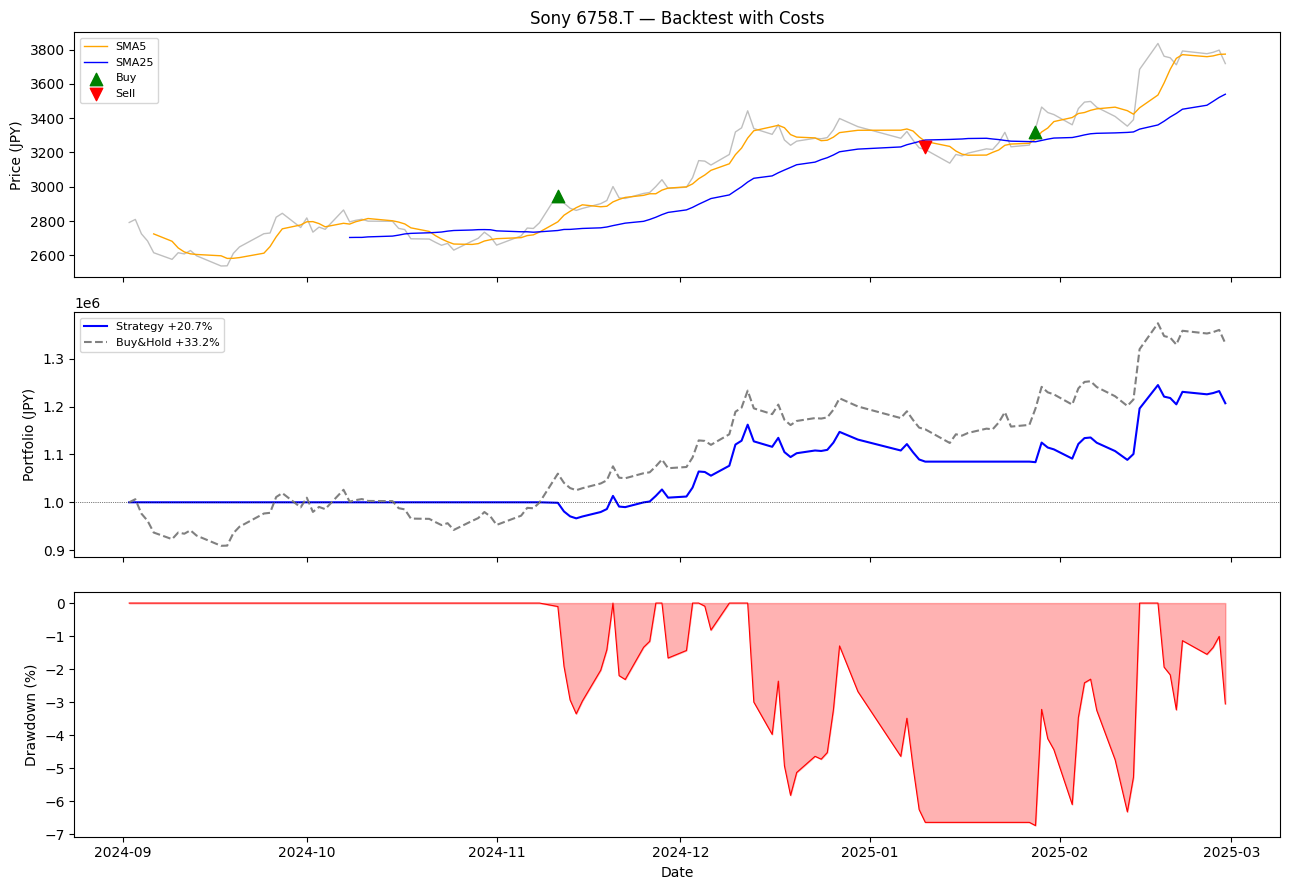

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. 数据准备 ────────────────────────────────────
df = yf.download("6758.T", start="2024-09-01", end="2025-03-01")
df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns
df.dropna(inplace=True)

df["SMA5"]  = df["Close"].rolling(5).mean()
df["SMA25"] = df["Close"].rolling(25).mean()
prev = df["SMA5"].shift(1) - df["SMA25"].shift(1)
curr = df["SMA5"] - df["SMA25"]
df["signal"] = 0
df.loc[(prev < 0) & (curr > 0), "signal"] =  1
df.loc[(prev > 0) & (curr < 0), "signal"] = -1

# ── 2. 成本参数 ────────────────────────────────────
INITIAL_CASH   = 1_000_000
COMMISSION     = 0.00055   # 手续费率 0.055%
SLIPPAGE       = 0.0005    # 滑点 0.05%
COST_PER_TRADE = COMMISSION + SLIPPAGE  # 单次交易总成本

# ── 3. 回测引擎（含成本）──────────────────────────
cash     = INITIAL_CASH
shares   = 0
position = False
records  = []
total_commission = 0

for date, row in df.iterrows():
    price = float(row["Close"])
    sig   = int(row["signal"])

    if sig == 1 and not position:
        # 买入价 = 收盘价 × (1 + 滑点)
        buy_price      = price * (1 + SLIPPAGE)
        shares         = int(cash / buy_price)
        commission     = shares * buy_price * COMMISSION
        cash          -= shares * buy_price + commission
        total_commission += commission
        position       = True
        action         = "BUY"
        exec_price     = buy_price

    elif sig == -1 and position:
        # 卖出价 = 收盘价 × (1 - 滑点)
        sell_price     = price * (1 - SLIPPAGE)
        commission     = shares * sell_price * COMMISSION
        cash          += shares * sell_price - commission
        total_commission += commission
        shares         = 0
        position       = False
        action         = "SELL"
        exec_price     = sell_price

    else:
        action     = "-"
        exec_price = price

    total = cash + shares * price
    records.append({
        "date"      : date,
        "price"     : price,
        "exec_price": exec_price,
        "action"    : action,
        "total"     : total,
    })

result = pd.DataFrame(records).set_index("date")

# ── 4. 夏普比率计算 ────────────────────────────────
# 夏普比率 = 年化超额收益 / 年化波动率
# 日本的无风险利率约0.1%（10年国债）
daily_returns   = result["total"].pct_change().dropna()
risk_free_daily = 0.001 / 252        # 年化0.1% → 日化
excess_returns  = daily_returns - risk_free_daily
sharpe_ratio    = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

# ── 5. 最大回撤（预告：今天先算，Day3详细讲）──────
rolling_max  = result["total"].cummax()
drawdown     = (result["total"] - rolling_max) / rolling_max
max_drawdown = drawdown.min() * 100

# ── 6. 绩效摘要 ────────────────────────────────────
final_total  = result["total"].iloc[-1]
strategy_ret = (final_total / INITIAL_CASH - 1) * 100
buyhold_ret  = (df["Close"].iloc[-1] / df["Close"].iloc[0] - 1) * 100

print("=" * 50)
print("  绩效摘要（含交易成本）")
print("=" * 50)
print(f"  初始资金         : ¥{INITIAL_CASH:>10,.0f}")
print(f"  最终资产         : ¥{final_total:>10,.0f}")
print(f"  策略收益率       : {strategy_ret:>+.2f}%")
print(f"  买入持有收益率   : {buyhold_ret:>+.2f}%")
print(f"  超额收益         : {strategy_ret - buyhold_ret:>+.2f}%")
print(f"  总手续费         : ¥{total_commission:>10,.0f}")
print("-" * 50)
print(f"  夏普比率         : {sharpe_ratio:>10.3f}")
print(f"  最大回撤         : {max_drawdown:>+.2f}%")
print("=" * 50)

# ── 7. 可视化（三图）─────────────────────────────
buyhold_curve = INITIAL_CASH * (df["Close"] / df["Close"].iloc[0])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# 上：股价
ax1.plot(df["Close"],  color="gray",   alpha=0.5, linewidth=1)
ax1.plot(df["SMA5"],   color="orange", linewidth=1, label="SMA5")
ax1.plot(df["SMA25"],  color="blue",   linewidth=1, label="SMA25")
buys  = result[result["action"] == "BUY"]
sells = result[result["action"] == "SELL"]
ax1.scatter(buys.index,  buys["price"]  * 0.995, marker="^", color="green", s=80, zorder=5, label="Buy")
ax1.scatter(sells.index, sells["price"] * 1.005, marker="v", color="red",   s=80, zorder=5, label="Sell")
ax1.set_ylabel("Price (JPY)")
ax1.legend(fontsize=8)
ax1.set_title("Sony 6758.T — Backtest with Costs")

# 中：资产曲线
ax2.plot(result.index, result["total"],      color="blue", linewidth=1.5, label=f"Strategy {strategy_ret:+.1f}%")
ax2.plot(buyhold_curve.index, buyhold_curve, color="gray", linewidth=1.5, linestyle="dashed", label=f"Buy&Hold {buyhold_ret:+.1f}%")
ax2.axhline(INITIAL_CASH, color="black", linewidth=0.5, linestyle="dotted")
ax2.set_ylabel("Portfolio (JPY)")
ax2.legend(fontsize=8)

# 下：回撤曲线
ax3.fill_between(drawdown.index, drawdown * 100, 0, color="red", alpha=0.3)
ax3.plot(drawdown.index, drawdown * 100, color="red", linewidth=0.8)
ax3.set_ylabel("Drawdown (%)")
ax3.set_xlabel("Date")

plt.tight_layout()
plt.show()